# Notebook Goal

### The goal of this notebook:
1. To understand the Titanic dataset
2. To perform different feature engineering and preprocessing
3. To discover new feature that could produce good insights
   
5. Continuous iteration of data analysis for each feature engineering


### Data dictionary

|Variable|Definition|Key|
|----------|------------|-----|
| survival | Survival   | 0 = No, 1 = Yes |
| pclass | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| sex | Sex | |
| age | Age in years | |
| sibsp | # of siblings / spouses aboard the Titanic | |
| parch | # of parents / children aboard the Titanic | |
| ticket | Ticket number | |
| fare | Passenger fare | |
| cabin | Cabin number | |
| embarked | Port of Embarkation | C = Cherbourg, Q = Queenstown, S = Southampton |

# Model to beat
 
Features:
1. Age
2. Class_1_Master
3. Deck
4. Embarked
5. Family_size
6. Fare
7. Is_adult
8. Is_solo
9. Male_class_3
10. Pclass
11. Sex
12. Survived
13. Title

Impute:
1. Fare mean by Pclass
2. Age median by Pclass and Sex
3. Cabin mode by Pclass and Is_Solo
4. Fill Embarked by S

Hot Encode:
1. Deck
2. Embarked
3. Sex
4. Title

Drop:
1. Age_bucket
2. Cabin
3. Class_2_Master 
4. Fare_per_pax
5. Female_class_1
6. Female_class_2
7. Male_class_2
8. Name
9. Parch
10. PassengerId
11. SibSp 
12. Ticket
13. Ticket_with_alpha
14. Total_ticket_holder

Scaler:
1. StandardScaler() | N/A for tree-based models


|Model|CV Score|CV std|Kaggle Score|
|----------|------------|-----|----|
|LogisticRegression(max_iter = 1000, random_state = SEED, C = 0.1, penalty='l2', solver ='lbfgs')|0.840619|0.020967||
|svm.SVC(kernel='linear',probability=True, random_state=SEED, C = 0.1)|0.828266|0.015494||
|svm.SVC(kernel='rbf', probability=True, random_state=SEED, C=1)|0.830507|0.013243||
|RandomForestClassifier(random_state=SEED, n_estimators=90, criterion='entropy', min_samples_split=20, max_depth = 15, min_samples_leaf=1, bootstrap=True, oob_score=True)|0.828266|0.837261||
|XGBClassifier(random_state=SEED, n_estimators=90, max_depth = 3, learning_rate=0.2, subsample=0.3, colsample_bytree = 0.2)|0.837261|0.018121||
|VotingClassifier(estimators=[('lr', lr_model),('svm_rbf', svm_rbf_model),('svm_lin', svm_lin_model),('rf', rf_model),('xgb', xgb_model)],voting='soft',weights=[1,0,0,1,1])|0.836137|0.014408|0.79665|
|StackingClassifier(estimators=[('lr', lr_model),('svm_rbf', svm_rbf_model),('svm_lin', svm_lin_model),('rf', rf_model),('xgb', xgb_model)],final_estimator=LogisticRegression())|0.835007|0.00858||


In [2]:
import sys
sys.path.append("..")

In [52]:
# import .py libraries
from src import load_dataset, show_missing_entries

# eda utils
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [4]:
train_set, test_set = load_dataset()

# Test Set

In [5]:
test_set.head(3)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q


In [6]:
test_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB


In [7]:
show_missing_entries(test_set)

,Column,Missing,Percentage
9,Cabin,327,78.23
4,Age,86,20.57
8,Fare,1,0.24


# Train Set

In [8]:
train_set.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [9]:
train_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [64]:
train_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.112424,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.304424,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,21.500000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,26.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,36.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [10]:
show_missing_entries(train_set)

,Column,Missing,Percentage
10,Cabin,687,77.10
5,Age,177,19.87
11,Embarked,2,0.22


## Sex

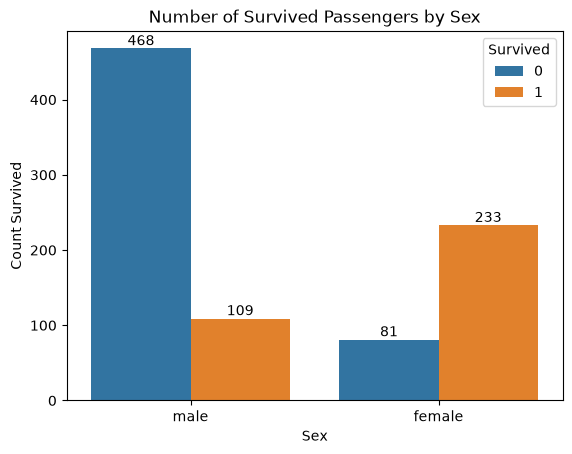

In [11]:
bar = sns.countplot(train_set, x = "Sex", hue="Survived")

for container in bar.containers:
    bar.bar_label(container)
    
plt.title('Number of Survived Passengers by Sex')
plt.xlabel('Sex')
plt.ylabel('Count Survived')
plt.show()

Text(0, 0.5, 'Number of Passengers')

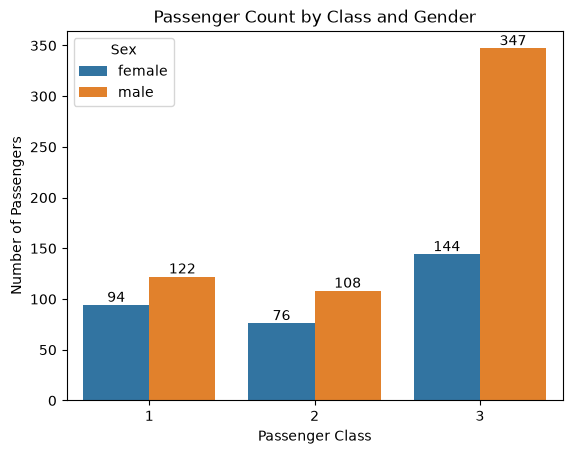

In [12]:
bar = sns.countplot(train_set, x = "Pclass", hue="Sex")

for container in bar.containers:
    bar.bar_label(container)
    
plt.title("Passenger Count by Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

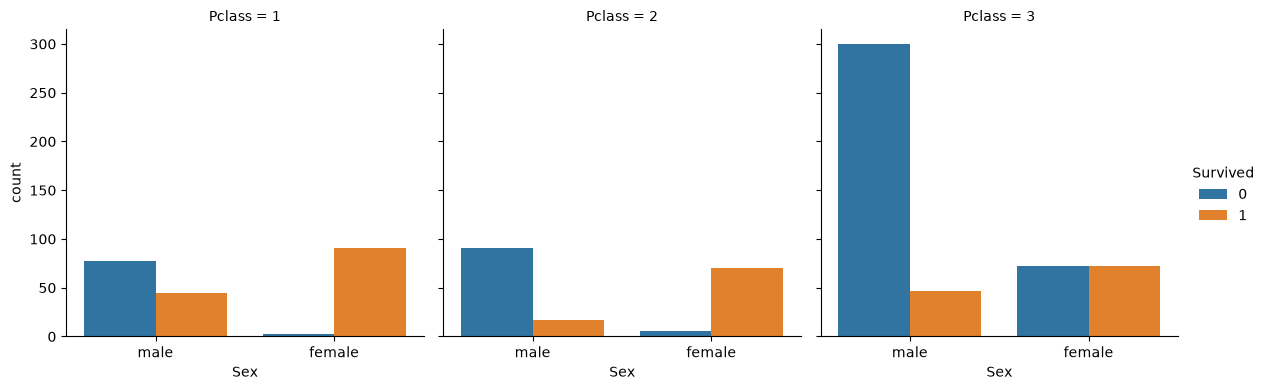

In [13]:
sns.catplot(
    data=train_set,
    x='Sex',
    hue='Survived',
    col='Pclass',
    kind='count',
    height=4,
    aspect=1
)

## Fare

<Axes: xlabel='Fare', ylabel='Count'>

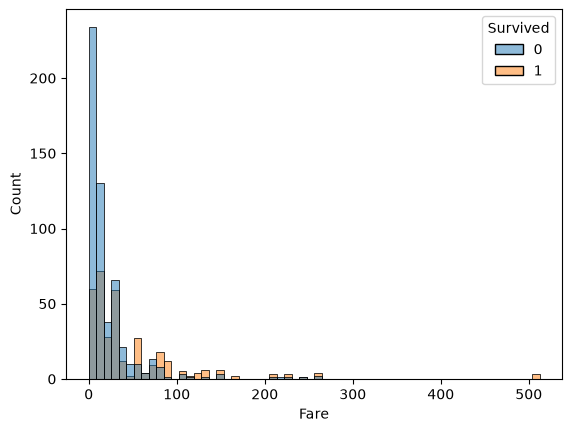

In [14]:
sns.histplot(train_set, x = "Fare", hue="Survived")

In [59]:
np.append(np.arange(0, 250, 25.0), float('inf'))

array([  0.,  25.,  50.,  75., 100., 125., 150., 175., 200., 225.,  inf])

<Axes: xlabel='Fare_bucket', ylabel='count'>

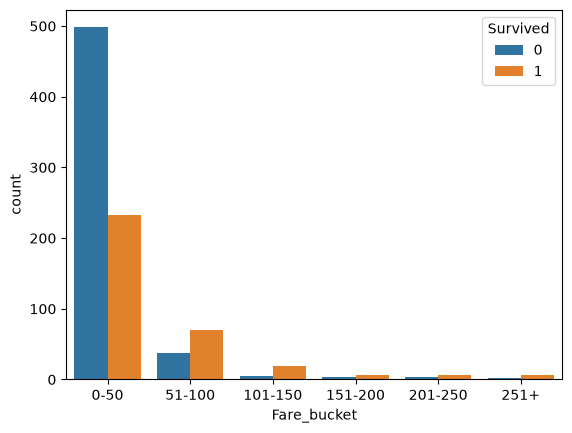

In [63]:
df = train_set.copy()
df['Fare_bucket'] = pd.cut(
    train_set['Fare'],
    bins=[0, 50, 100, 150, 200, 250, float('inf')],
    labels=[
        '0-50',
        '51-100',
        '101-150',
        '151-200',
        '201-250',
        '251+'
        ],
    include_lowest=True
)

sns.countplot(df, x="Fare_bucket", hue = "Survived")

In [15]:
df = train_set.copy()
df[df['Fare'] > 400]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [16]:
train_set.groupby(['Pclass','Sex'])['Fare'].mean()

Pclass  Sex   
1       female    106.125798
        male       67.226127
2       female     21.970121
        male       19.741782
3       female     16.118810
        male       12.661633
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Survived = False')

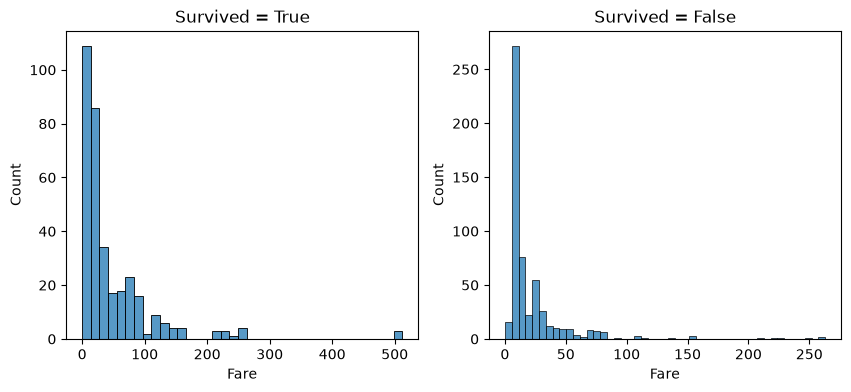

In [17]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

sns.histplot(train_set[train_set['Survived'] == 1], x = "Fare", ax=axs[0])
axs[0].set_title("Survived = True")

sns.histplot(train_set[train_set['Survived'] == 0], x = "Fare", ax=axs[1])
axs[1].set_title("Survived = False")

## Embarked

In [18]:
train_set[train_set['Embarked'].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


**According to historical facts, Miss Amelie and Mrs. George Nelson embarked on Southampton**

In [19]:
train_set['Embarked'] = train_set['Embarked'].fillna('S')

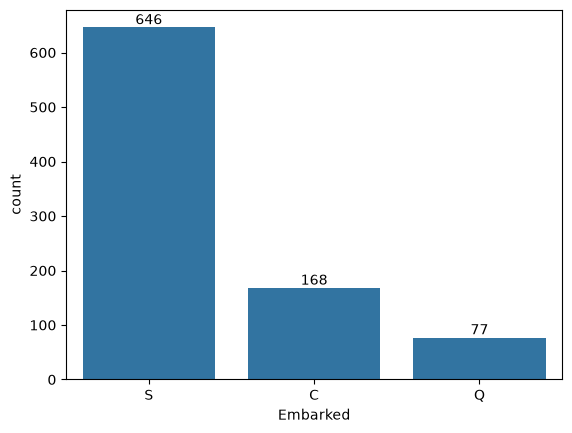

In [34]:
bar = sns.countplot(train_set, x = "Embarked")

for container in bar.containers:
    bar.bar_label(container)

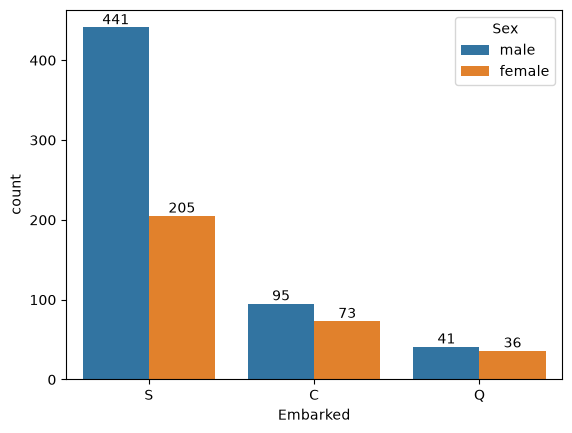

In [20]:
bar = sns.countplot(train_set, x = "Embarked", hue="Sex")

for container in bar.containers:
    bar.bar_label(container)

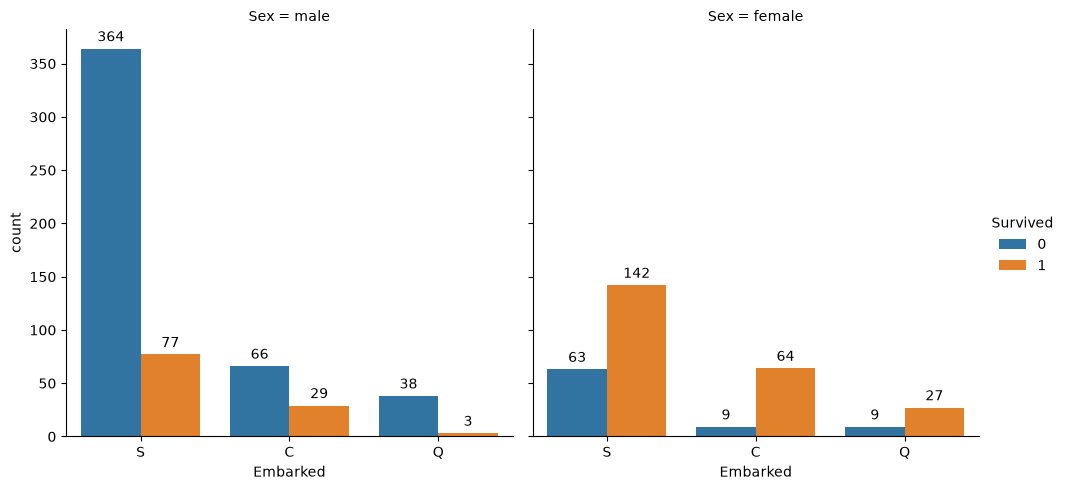

In [21]:
g = sns.catplot(train_set, x = "Embarked", hue="Survived", kind="count", col="Sex")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

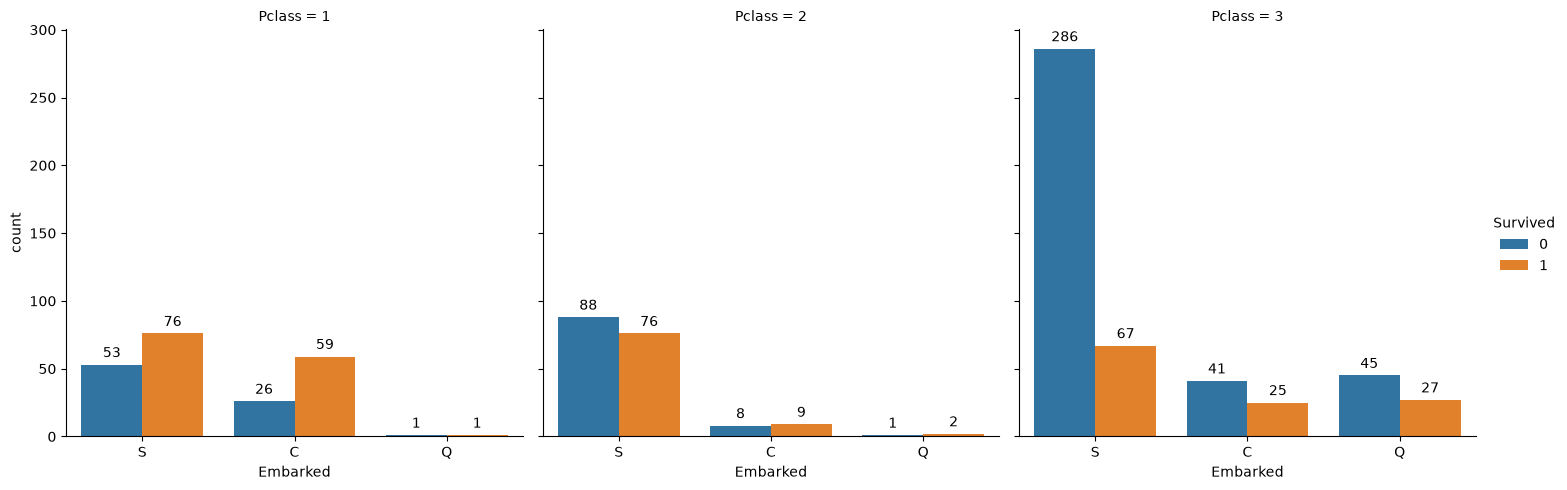

In [22]:
g = sns.catplot(train_set, x = "Embarked", hue="Survived", kind="count", col="Pclass")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

## Age

In [23]:
train_set.corr(numeric_only=True)['Age'].sort_values(ascending=False)

Age            1.000000
Fare           0.096067
PassengerId    0.036847
Survived      -0.077221
Parch         -0.189119
SibSp         -0.308247
Pclass        -0.369226
Name: Age, dtype: float64

**Pclass has the highest magnitude of correlation with Age. Thus, it is a good candidates for imputing missing Age values. To make it more distinct and meaningful, I can also use Sex.**

<Axes: xlabel='Age', ylabel='Count'>

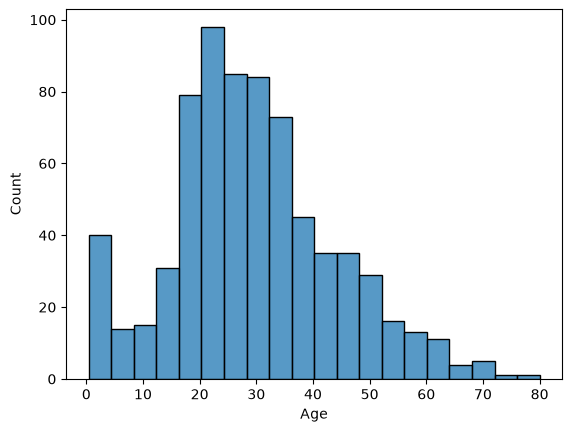

In [24]:
# current distribution
sns.histplot(train_set, x="Age")

In [25]:
age_median_by_pclass_sex = train_set.groupby(['Pclass', 'Sex'])['Age'].transform('median')

In [26]:
train_set['Age'] = df['Age'].fillna(age_median_by_pclass_sex)

<Axes: xlabel='Age', ylabel='Count'>

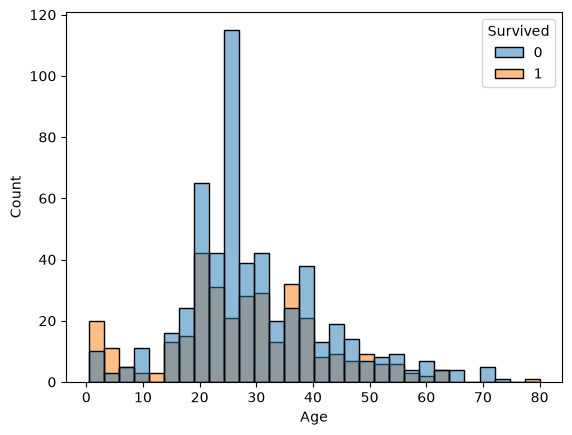

In [27]:
# updated/imputed distribution
sns.histplot(train_set, x="Age", hue='Survived', bins=30)

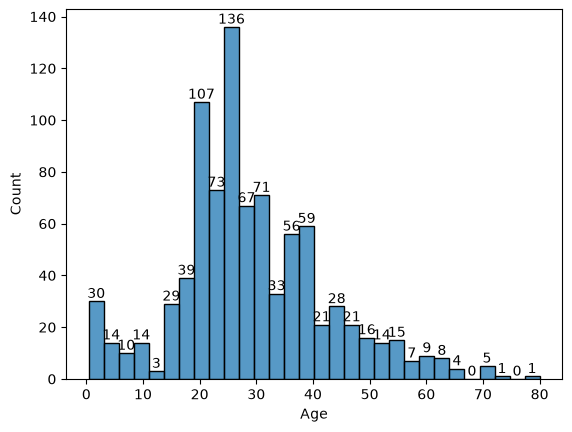

In [44]:
bar = sns.histplot(train_set, x="Age", bins=30)
for container in bar.containers:
    bar.bar_label(container)

<Axes: xlabel='Age', ylabel='count'>

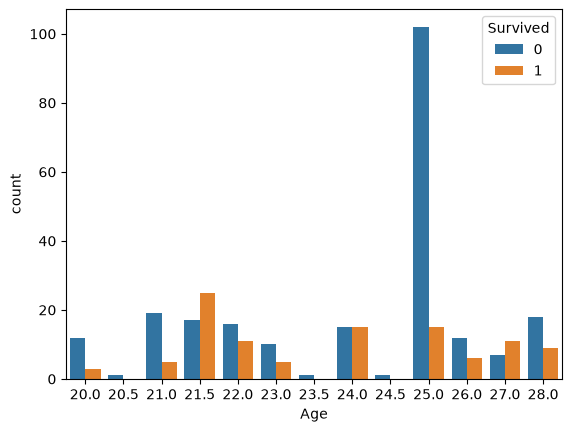

In [28]:
df = train_set[(train_set['Age'] >= 20) & (train_set['Age'] <= 28)]
sns.countplot(df, x="Age", hue="Survived")

<Axes: xlabel='Age', ylabel='count'>

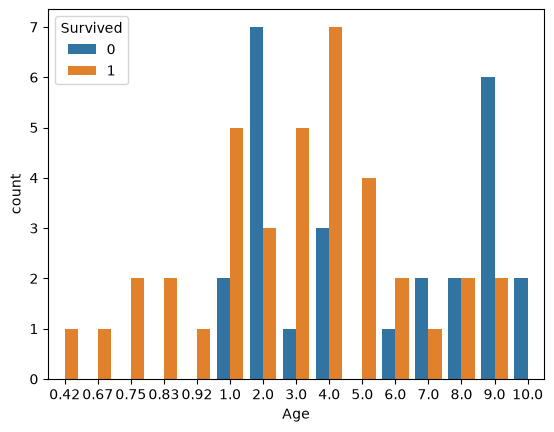

In [45]:
df = train_set[(train_set['Age'] >= 0) & (train_set['Age'] <= 10)]
sns.countplot(df, x="Age", hue="Survived")

<Axes: xlabel='Age_bucket', ylabel='count'>

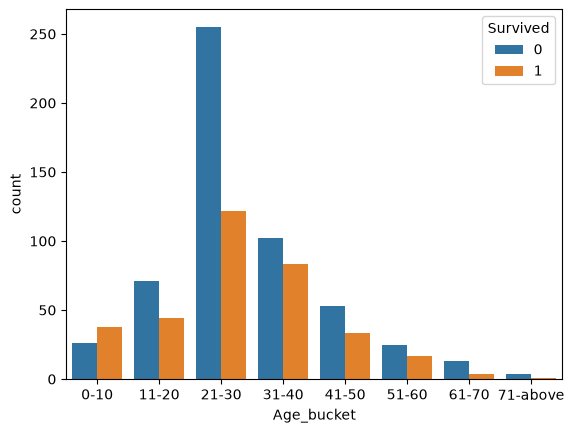

In [69]:
df = train_set.copy()
df['Age_bucket'] = pd.cut(
    df['Age'],
    bins=[0, 10, 20, 30, 40, 50, 60, 70, float('inf')], # 11 edges = 10 bins
    labels=[
        '0-10', '11-20', '21-30', '31-40', '41-50', 
        '51-60', '61-70', '71-above'
    ],
    include_lowest=True
)

sns.countplot(df, x="Age_bucket", hue = "Survived")

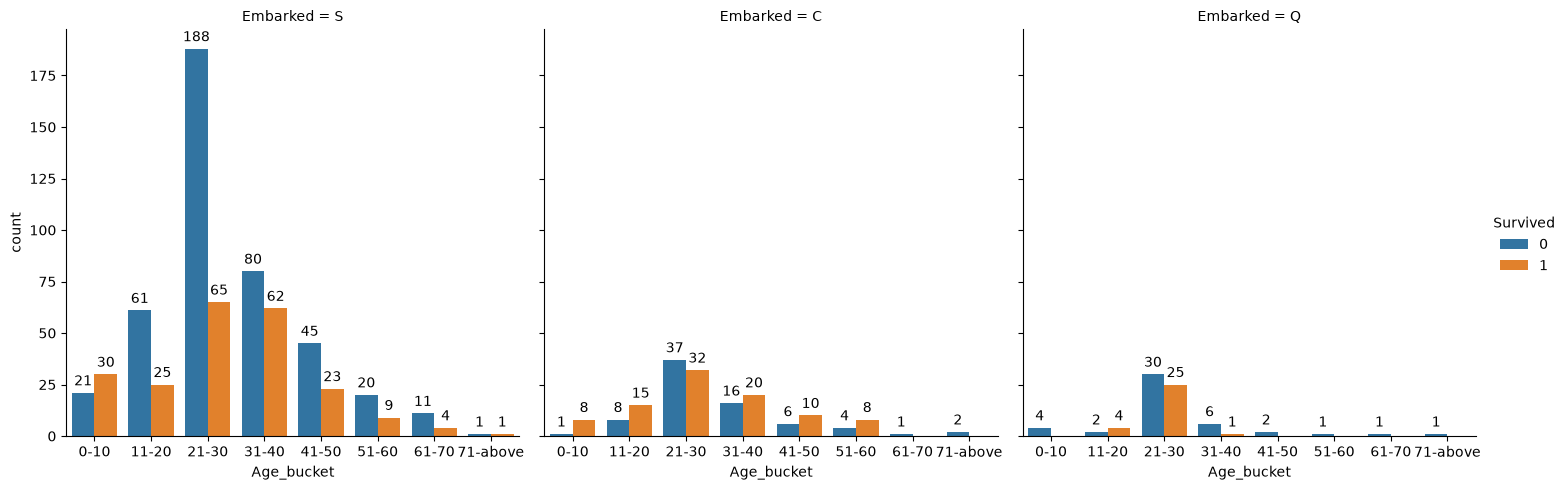

In [70]:
g = sns.catplot(df, x = "Age_bucket", hue="Survived", kind="count", col="Embarked")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

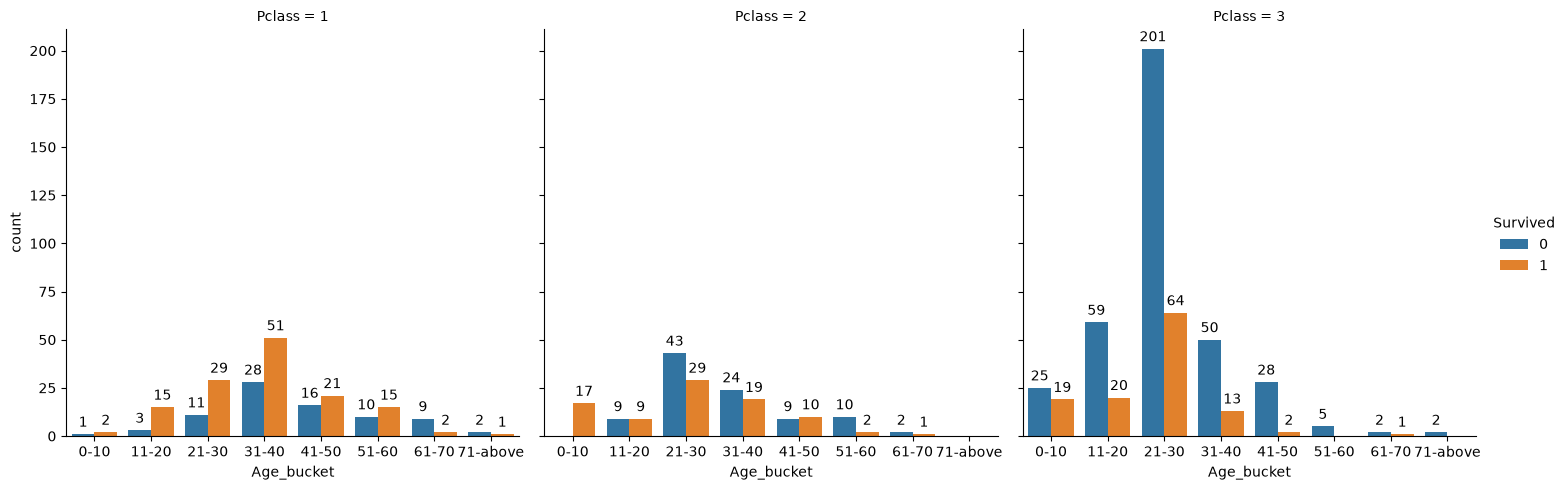

In [71]:
g = sns.catplot(df, x = "Age_bucket", hue="Survived", kind="count", col="Pclass")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

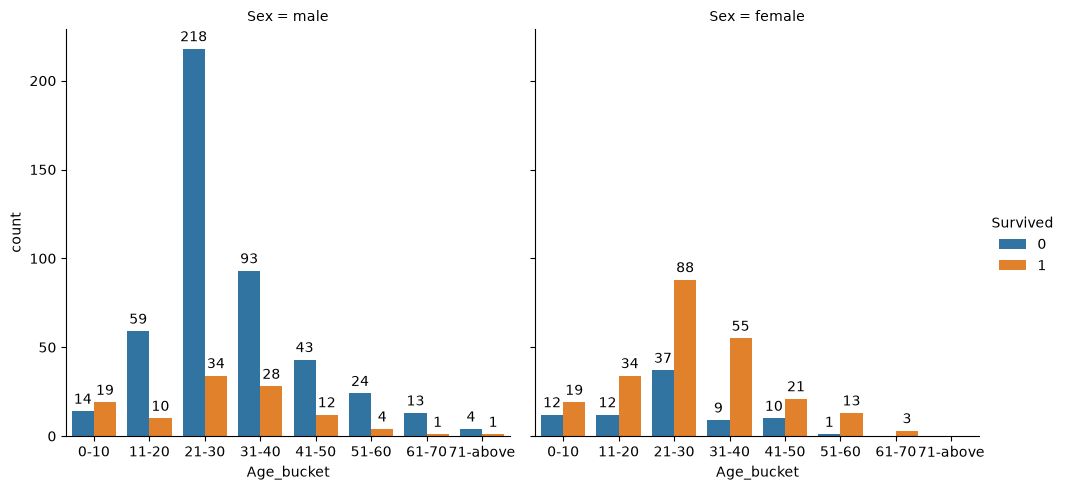

In [72]:
g = sns.catplot(df, x = "Age_bucket", hue="Survived", kind="count", col="Sex")

for ax in g.axes.flat:
    # Loop through the bar containers within that specific subplot
    for container in ax.containers:
        ax.bar_label(container, fontsize=10, padding=3)

## Cabin

<Axes: xlabel='Survived', ylabel='count'>

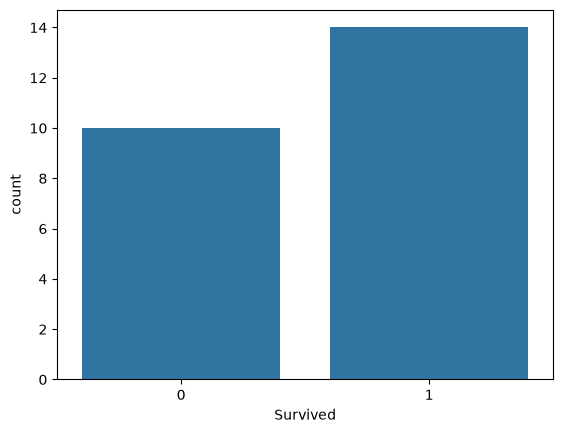

In [81]:
df = train_set[train_set['Cabin'].str.contains(" ")]
sns.countplot(df, x = 'Survived')

<Axes: xlabel='Survived', ylabel='count'>

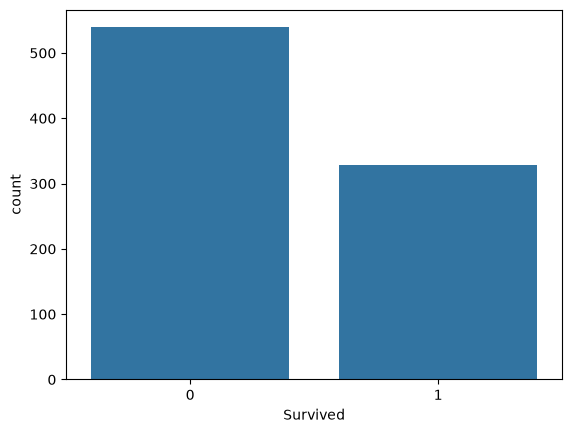

In [82]:
df = train_set[train_set['Cabin'].str.contains(" ") == False]
sns.countplot(df, x = 'Survived')

In [92]:
train_set[train_set['Cabin'].str.contains(" ")].value_counts('Cabin')

Cabin
C23 C25 C27        4
B96 B98            4
C22 C26            3
F G73              2
B58 B60            2
B57 B59 B63 B66    2
B51 B53 B55        2
D10 D12            1
F E69              1
F G63              1
C62 C64            1
B82 B84            1
Name: count, dtype: int64

In [85]:
train_set['Deck'] = train_set['Cabin'].str[0]

<Axes: xlabel='Deck', ylabel='count'>

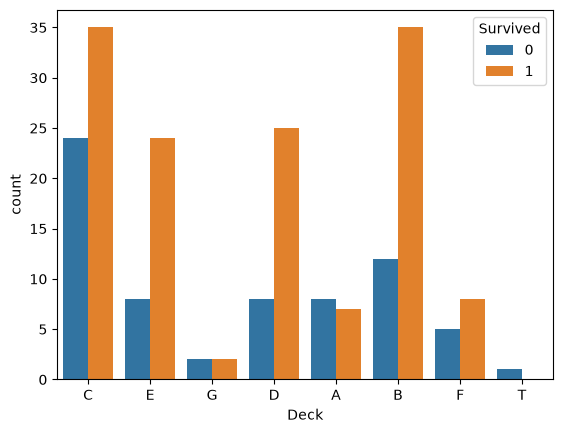

In [88]:
sns.countplot(train_set, x = 'Deck', hue='Survived')

<Axes: xlabel='Deck', ylabel='count'>

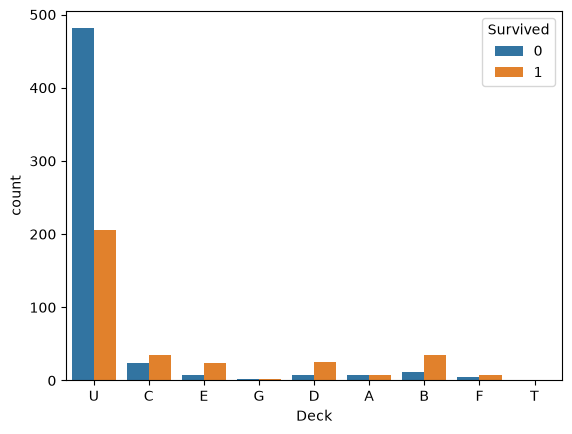

In [101]:
df = train_set.copy()
df['Deck'] = df['Deck'].fillna('U')
sns.countplot(df, x = 'Deck', hue='Survived')

Text(0.5, 1.0, 'Unknown Deck by Embarked')

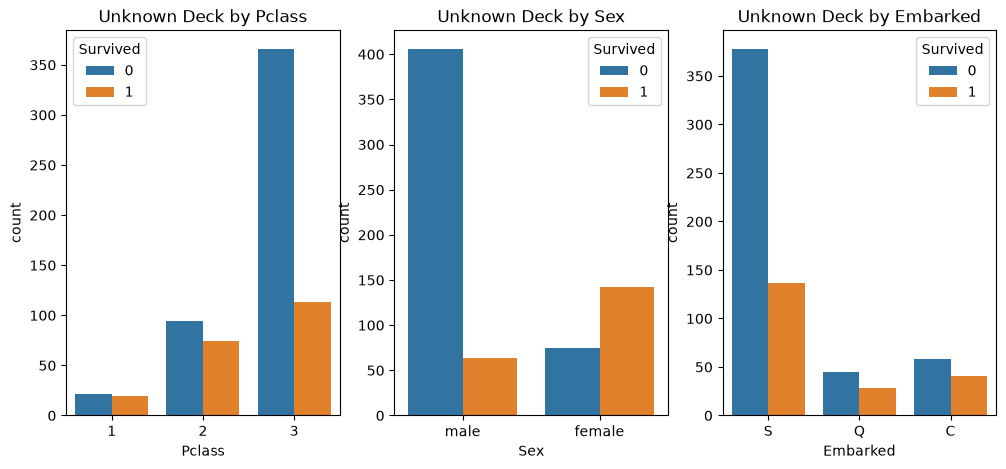

In [100]:
df_unknown = df[df['Deck'] == 'U']

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

sns.countplot(df_unknown, x = "Pclass", ax = axes[0], hue='Survived')
axes[0].set_title('Unknown Deck by Pclass')

sns.countplot(df_unknown, x = "Sex", ax = axes[1], hue='Survived')
axes[1].set_title('Unknown Deck by Sex')

sns.countplot(df_unknown, x = "Embarked", ax = axes[2], hue='Survived')
axes[2].set_title('Unknown Deck by Embarked')

**Using the 'Unknown' deck distribution across Pclass, Sex, and Embarked, I can derive interaction features that may contain insights**

## SibSp and Parch

In [106]:
train_set['Family_size'] = train_set['SibSp'] + train_set['Parch'] + 1

In [107]:
train_set.value_counts('Family_size')

Family_size
1     537
2     161
3     102
4      29
6      22
5      15
7      12
11      7
8       6
Name: count, dtype: int64

<Axes: xlabel='Family_size', ylabel='count'>

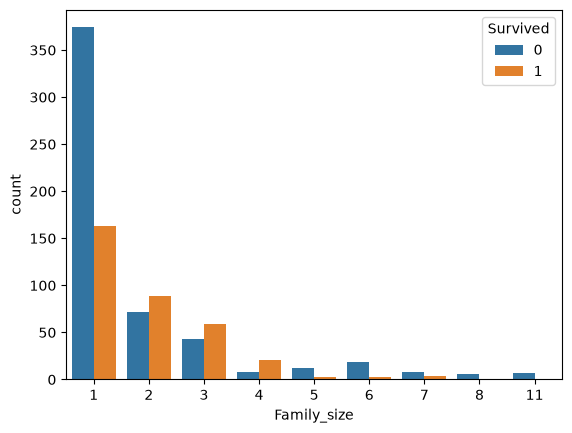

In [108]:
df = train_set.copy()

sns.countplot(df, x = 'Family_size', hue='Survived')

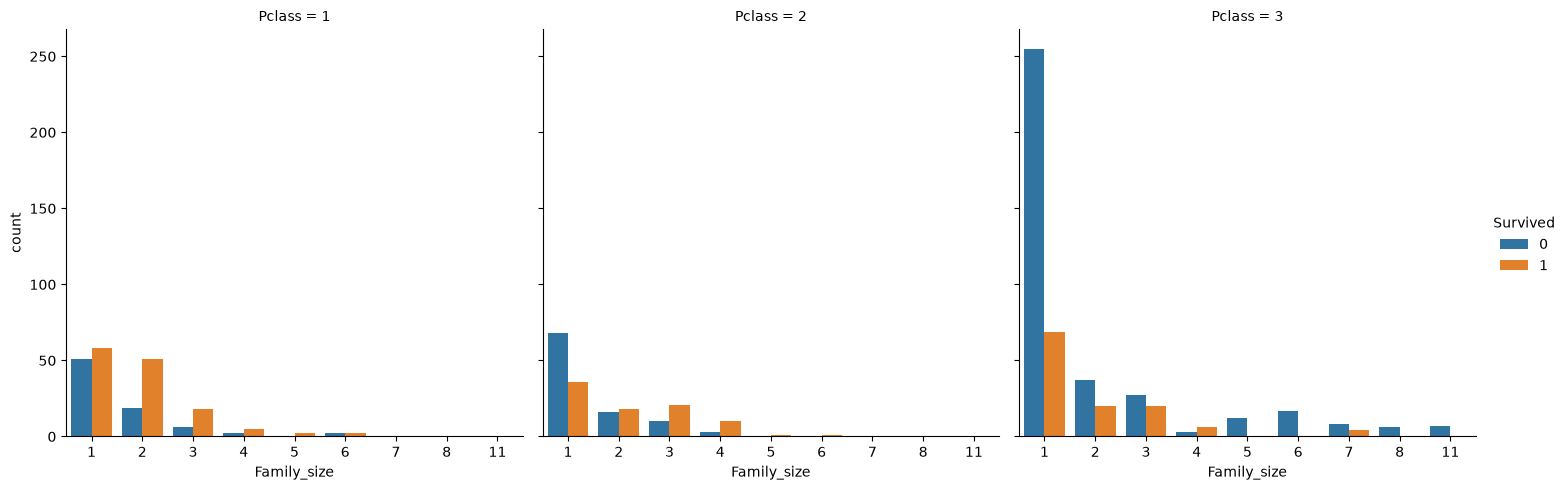

In [112]:
sns.catplot(df, x = 'Family_size', hue = 'Survived', col = 'Pclass', kind = 'count')

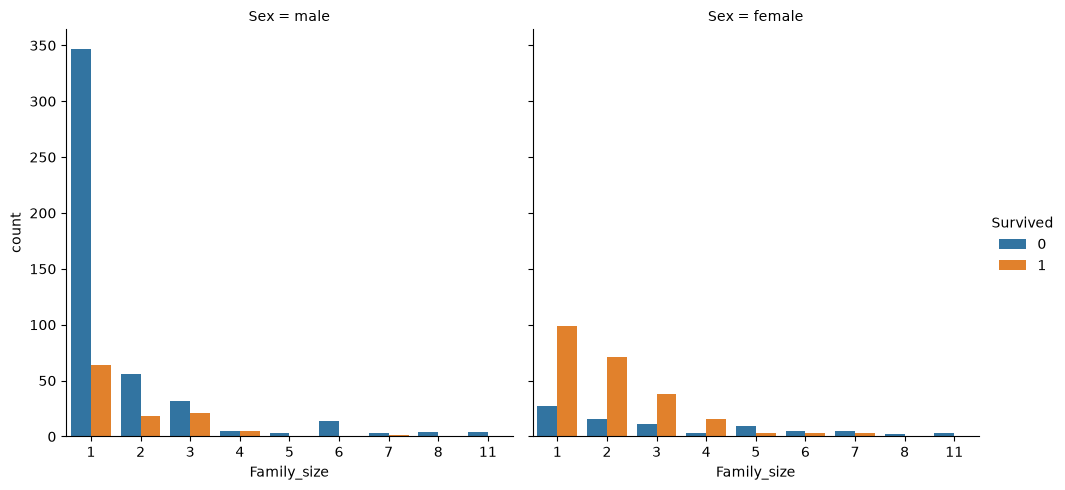

In [113]:
sns.catplot(df, x = 'Family_size', hue = 'Survived', col = 'Sex', kind = 'count')

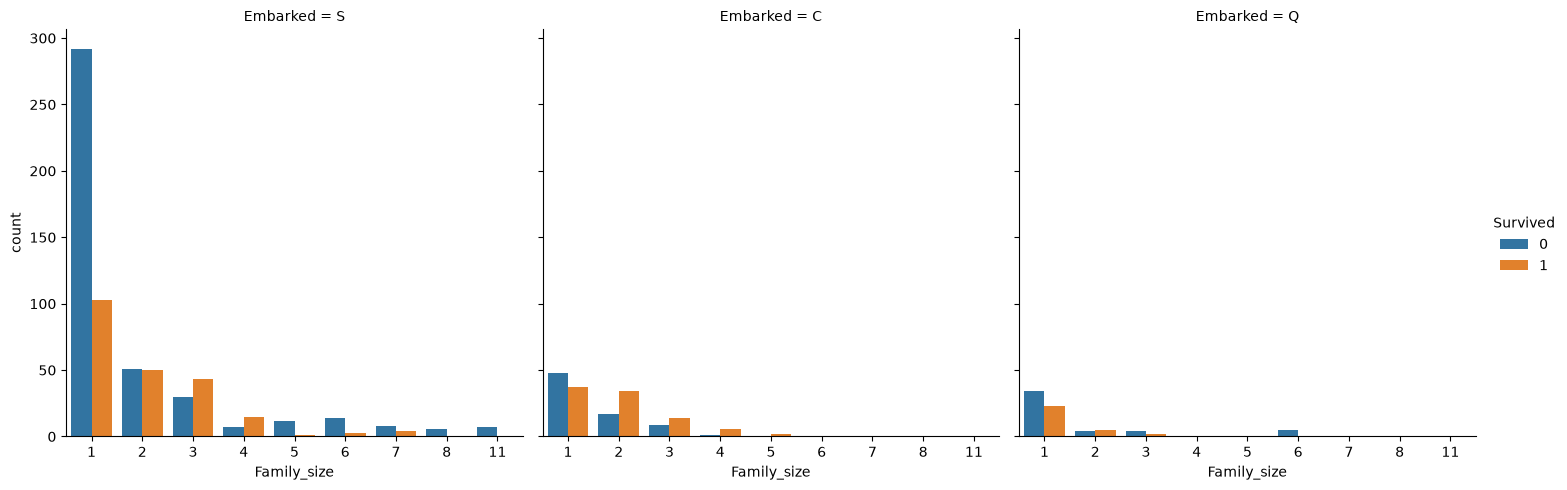

In [114]:
sns.catplot(df, x = 'Family_size', hue = 'Survived', col = 'Embarked', kind = 'count')

In [115]:
train_set['Is_solo'] = (train_set['Family_size'] == 1)

<Axes: xlabel='Is_solo', ylabel='count'>

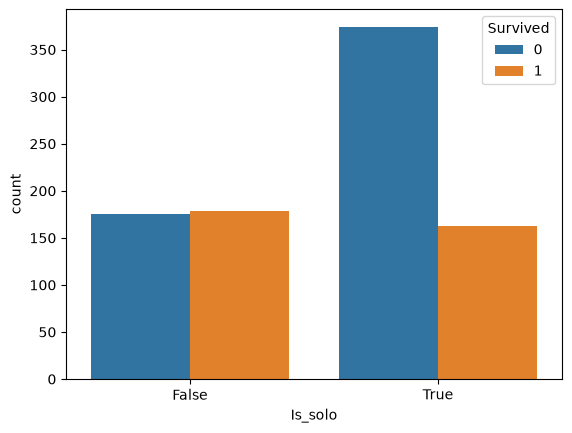

In [116]:
df = train_set.copy()

sns.countplot(df, x = 'Is_solo', hue='Survived')

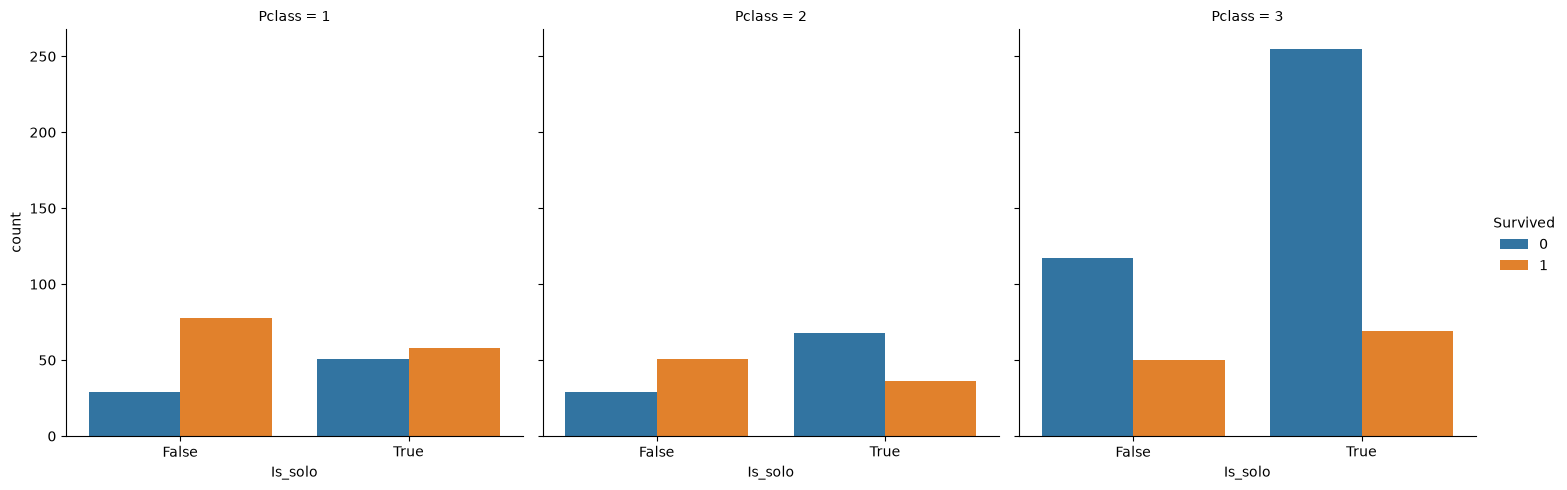

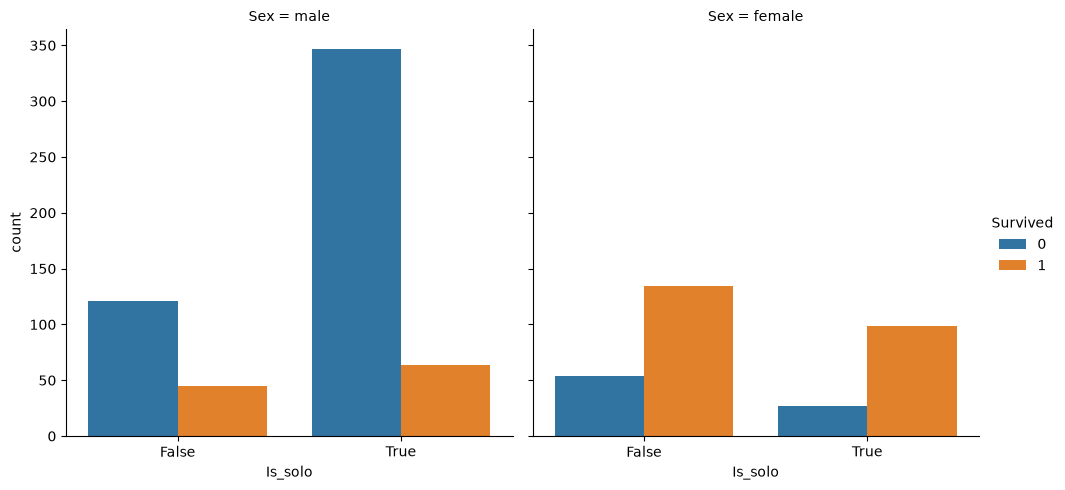

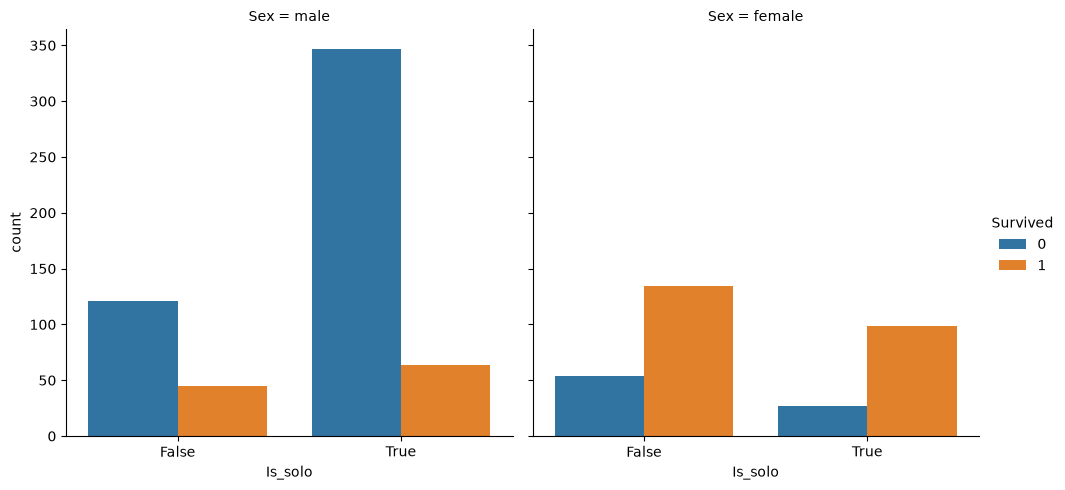

In [117]:
sns.catplot(df, x = 'Is_solo', hue = 'Survived', col = 'Pclass', kind = 'count')
sns.catplot(df, x = 'Is_solo', hue = 'Survived', col = 'Sex', kind = 'count')
sns.catplot(df, x = 'Is_solo', hue = 'Survived', col = 'Sex', kind = 'count')

## Name

In [118]:
train_set.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Deck,Family_size,Is_solo
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,NaN,2,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,C,2,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,NaN,1,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,C,2,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,NaN,1,True


In [125]:
train_set['Title'] = train_set["Name"].str.extract(
      r',\s*(.*?)\.',
      expand=False
)

In [126]:
train_set.value_counts('Title')

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

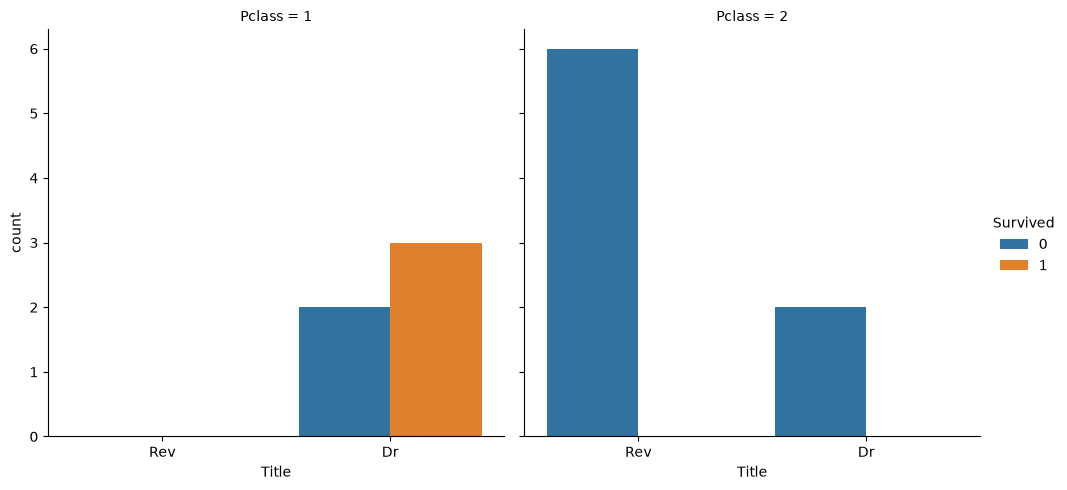

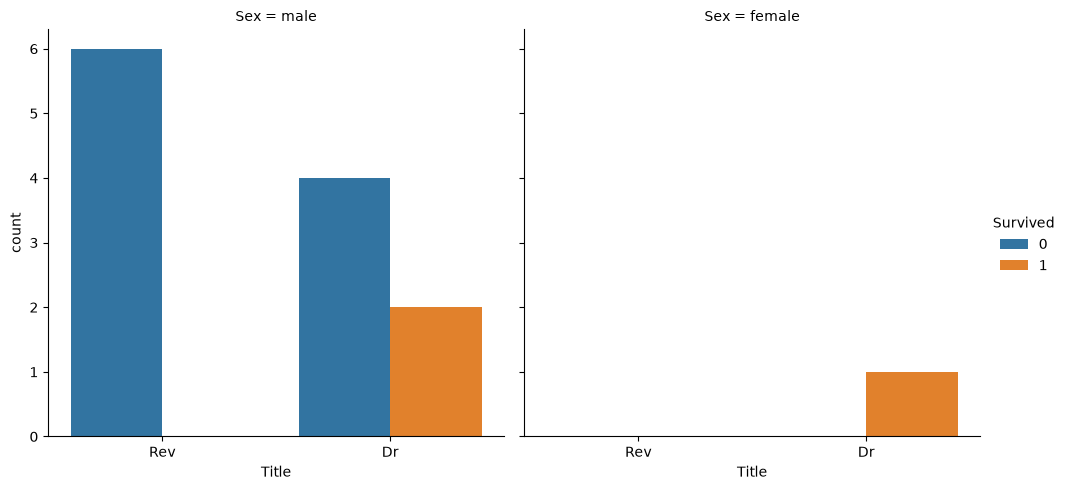

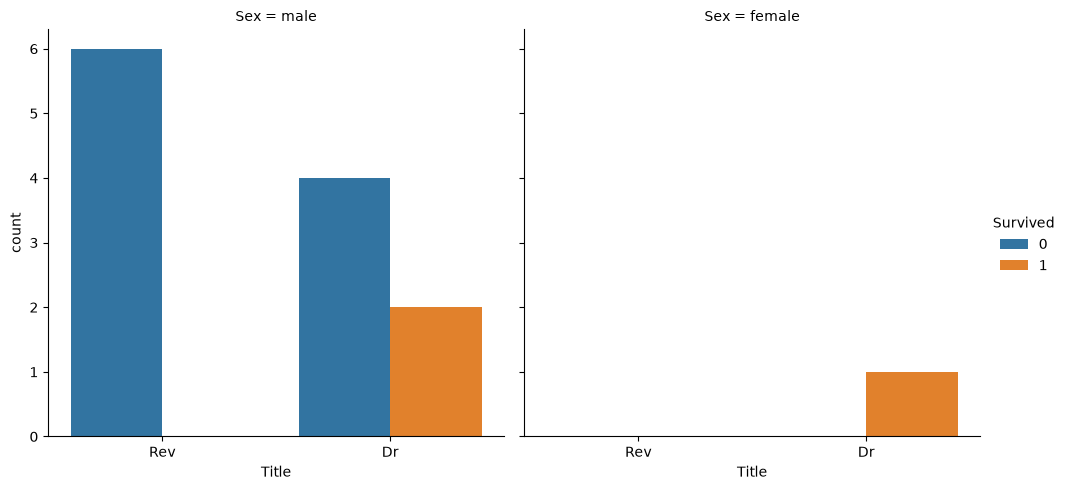

In [131]:
df = train_set.copy()
df = df[df['Title'].isin(['Dr','Rev'])]
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Pclass', kind = 'count')
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Sex', kind = 'count')
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Sex', kind = 'count')

In [121]:
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
train_set['Title'] = train_set['Title'].where(train_set['Title'].isin(common_titles), 'Rare')

In [122]:
train_set.value_counts('Title')

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

<Axes: xlabel='Title', ylabel='count'>

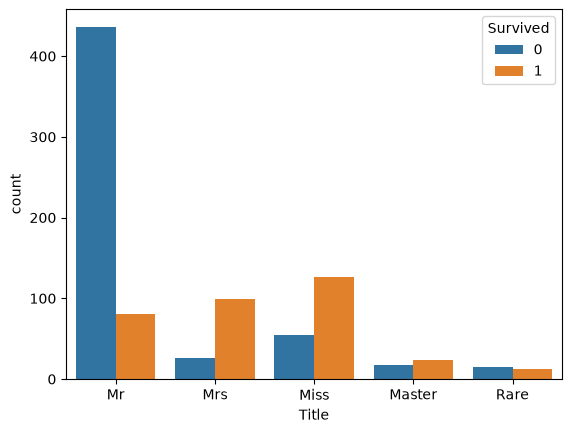

In [123]:
df = train_set.copy()

sns.countplot(df, x = 'Title', hue='Survived')

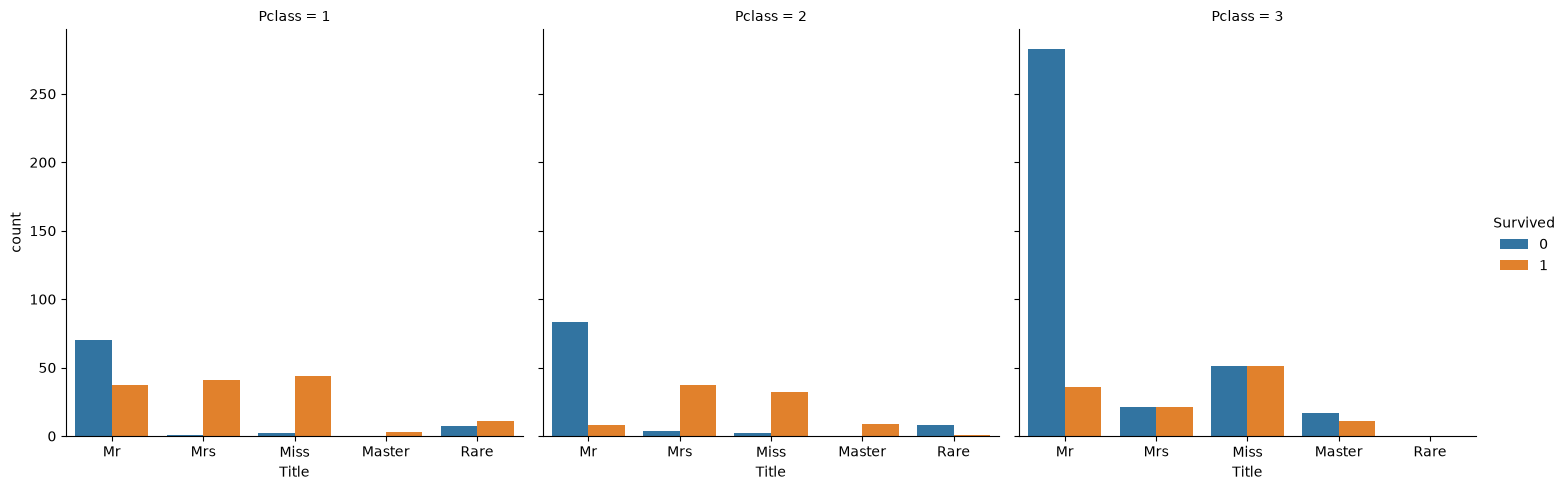

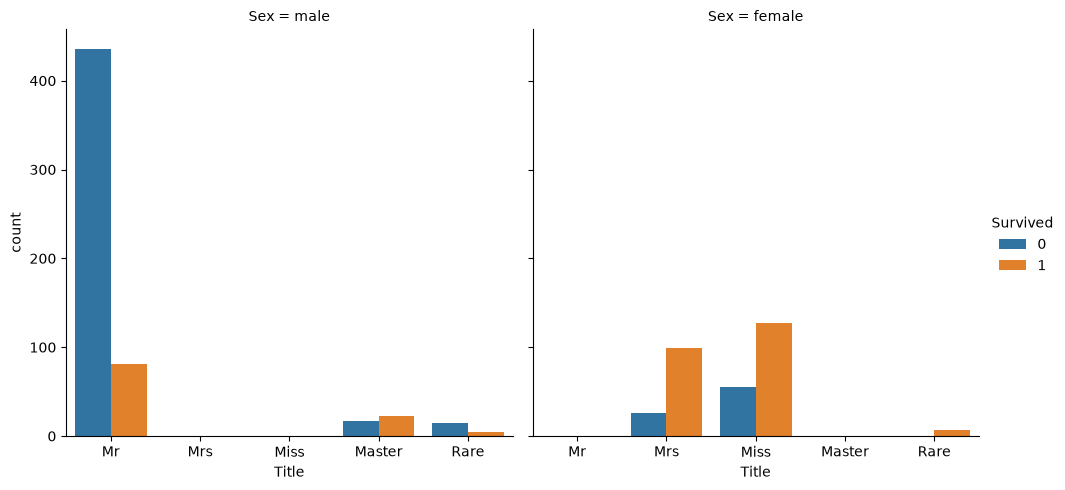

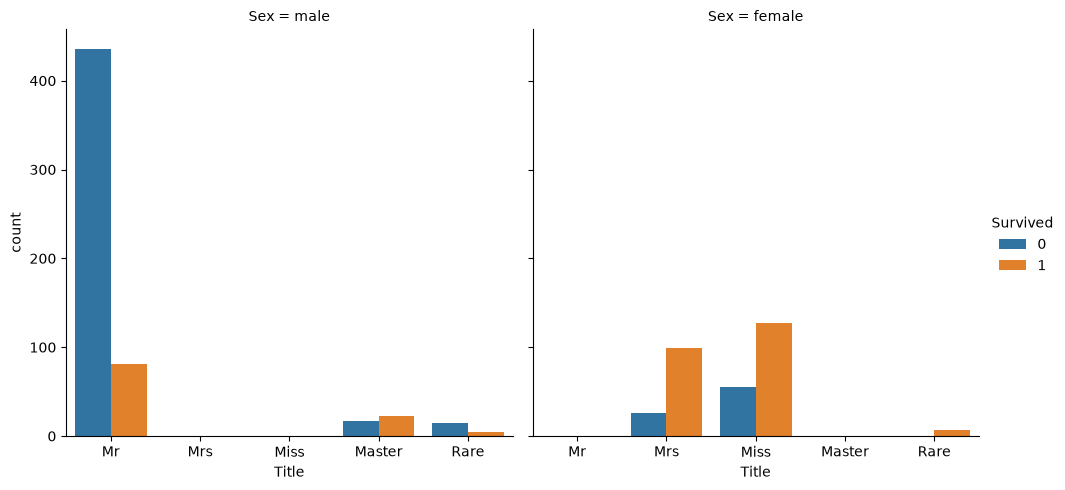

In [124]:
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Pclass', kind = 'count')
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Sex', kind = 'count')
sns.catplot(df, x = 'Title', hue = 'Survived', col = 'Sex', kind = 'count')

## Ticket

In [133]:
train_set['Ticket'].head(5)

0           A/5 21171
1            PC 17599
2    STON/O2. 3101282
3              113803
4              373450
Name: Ticket, dtype: str

In [135]:
split_df = train_set['Ticket'].str.split(' ', expand=True)

print(split_df)

            0        1    2
0         A/5    21171  NaN
1          PC    17599  NaN
2    STON/O2.  3101282  NaN
3      113803      NaN  NaN
4      373450      NaN  NaN
..        ...      ...  ...
886    211536      NaN  NaN
887    112053      NaN  NaN
888     W./C.     6607  NaN
889    111369      NaN  NaN
890    370376      NaN  NaN

[891 rows x 3 columns]


In [142]:
split_df[split_df[0].str.match(r'[A-Za-z]')].value_counts(0).sort_index()

0
A./5.          2
A.5.           2
A/4            3
A/4.           3
A/5           10
A/5.           7
A/S            1
A4.            1
C              5
C.A.          27
C.A./SOTON     1
CA             6
CA.            8
F.C.           1
F.C.C.         5
Fa             1
LINE           4
P/PP           2
PC            60
PP             3
S.C./A.4.      1
S.C./PARIS     2
S.O./P.P.      3
S.O.C.         5
S.O.P.         1
S.P.           1
S.W./PP        1
SC             1
SC/AH          3
SC/PARIS       5
SC/Paris       4
SCO/W          1
SO/C           1
SOTON/O.Q.     8
SOTON/O2       2
SOTON/OQ       7
STON/O        12
STON/O2.       6
SW/PP          1
W./C.          9
W.E.P.         1
W/C            1
WE/P           2
Name: count, dtype: int64

In [149]:
df = train_set.copy()
df['Is_ticket_num'] = (df['Ticket'].str.match(r'[A-Za-z]') == False)

In [151]:
df[df['Is_ticket_num'] == False].value_counts('Ticket')

Ticket
CA. 2343            7
CA 2144             6
S.O.C. 14879        5
W./C. 6608          4
LINE                4
                   ..
PC 17592            1
SC/PARIS 2149       1
PC 17590            1
C.A./SOTON 34068    1
SOTON/OQ 392076     1
Name: count, Length: 167, dtype: int64

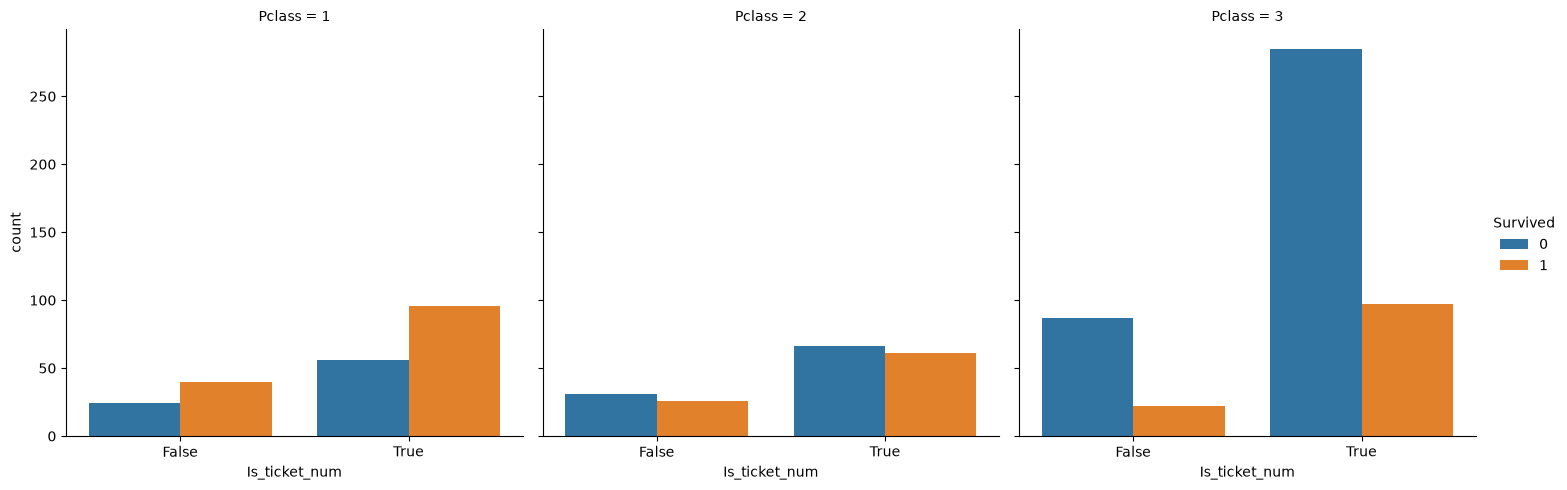

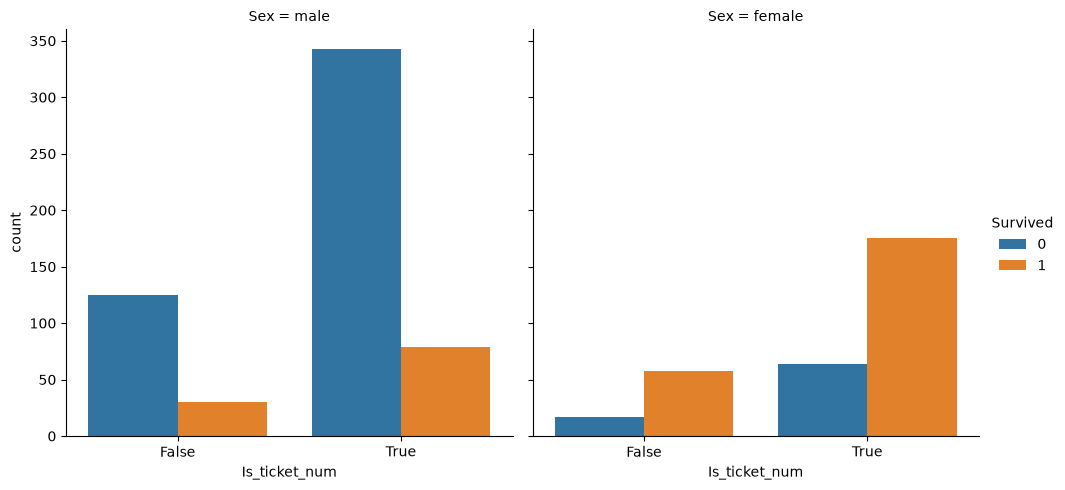

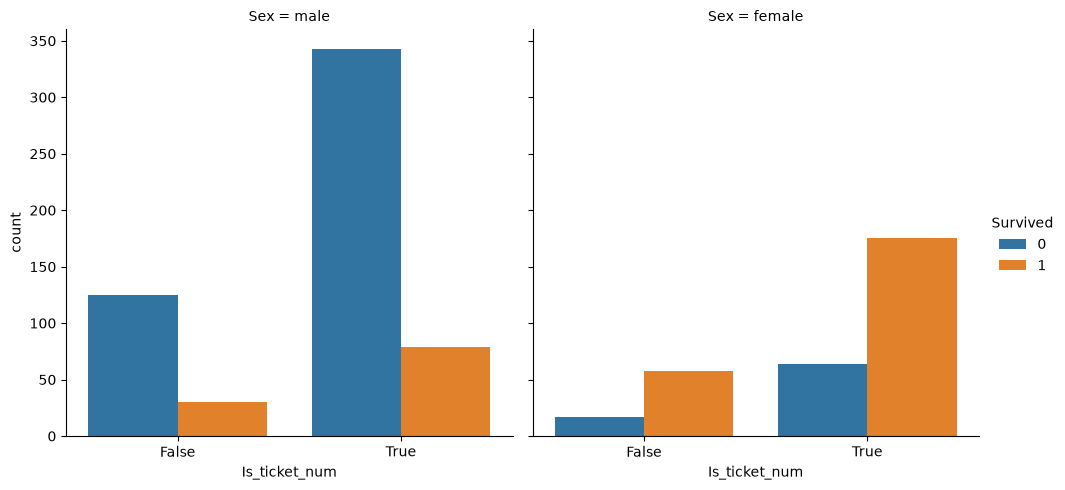

In [144]:
sns.catplot(df, x = 'Is_ticket_num', hue = 'Survived', col = 'Pclass', kind = 'count')
sns.catplot(df, x = 'Is_ticket_num', hue = 'Survived', col = 'Sex', kind = 'count')
sns.catplot(df, x = 'Is_ticket_num', hue = 'Survived', col = 'Sex', kind = 'count')

In [146]:
df = train_set.copy()
df['Ticket_str_0'] = df['Ticket'].str[0]

In [147]:
df.value_counts('Ticket_str_0')

Ticket_str_0
3    301
2    183
1    146
P     65
S     65
C     47
A     29
W     13
4     10
7      9
F      7
6      6
L      4
5      3
8      2
9      1
Name: count, dtype: int64

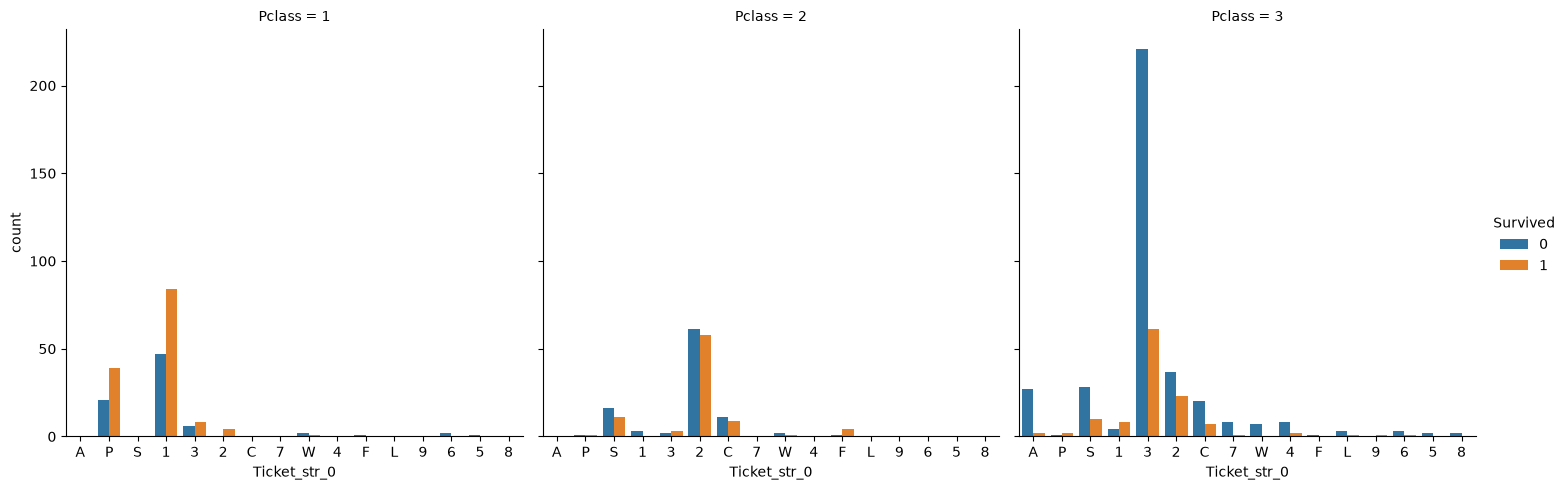

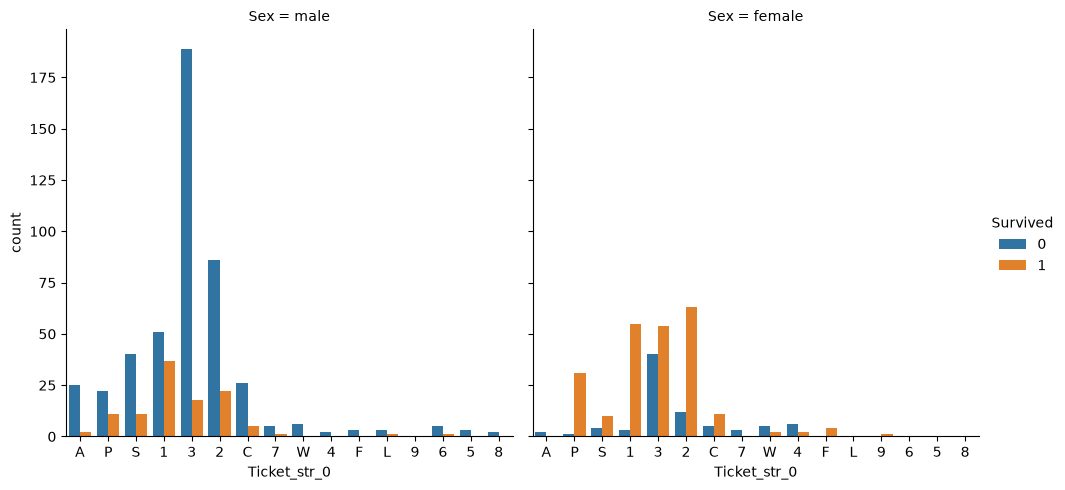

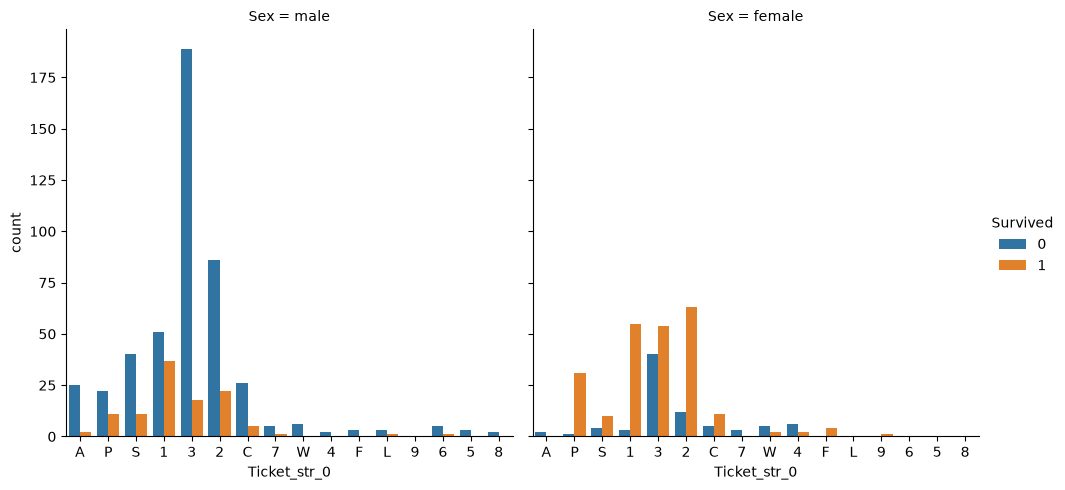

In [148]:
sns.catplot(df, x = 'Ticket_str_0', hue = 'Survived', col = 'Pclass', kind = 'count')
sns.catplot(df, x = 'Ticket_str_0', hue = 'Survived', col = 'Sex', kind = 'count')
sns.catplot(df, x = 'Ticket_str_0', hue = 'Survived', col = 'Sex', kind = 'count')